# Frequentist Versus Bayesian Analysis

(Ref: Frequentism and Bayesianism: A Python-driven Primer by Jake VanderPlas

Youtube video: Frequentism and Bayesianism: What's the Big Deal? | SciPy 2014 | Jake VanderPlas)

There are two main approaches in Statistics theory: Frequentisim and Bayesianism. 

## The fundamental difference between these approaches concerns the definition of probability. 

### For a frequentist probability is related to the frequencies of the repeated events. 

### However, for a Bayesian the probability is related to the certainty or uncertainty of the events. 

Let us consider an example of an astronomer measures the photon flux, $F$, from a given non-variable star (which mean the intrinsic flux of the star does not vary or in other words the star's true photon flux remains constant with time). Ignoring the background and systematic errors, let us assume a series of $N$ measurements are performed, where the $i$th measurement has the observed flux, $F_i$ and error, $e_i$. 

## The question is given this set of measurements, $D = \{F_i, e_i\}$, what is our best estimate of the true flux, $F$?

In [2]:
# Generating some simple photon count data
import numpy as np
from scipy import stats
np.random.seed(1)  # for repeatability

F_true = 1000  # true flux, say number of photons measured in 1 second
N = 500 # number of measurements
F = stats.poisson(F_true).rvs(N)  # N measurements of the flux
e = np.sqrt(F)  # errors on Poisson counts estimated via square root

Note: In a Frequentist perspective, $e_i$ is the standard deviation of the results of the single measurement event in the limit of (imaginary) repetitions of that event. Whereas in the Bayesian perspective, $e_i$ describes the probability distribution which quantifies our knowledge of $F$ given the measured value $F_i$.

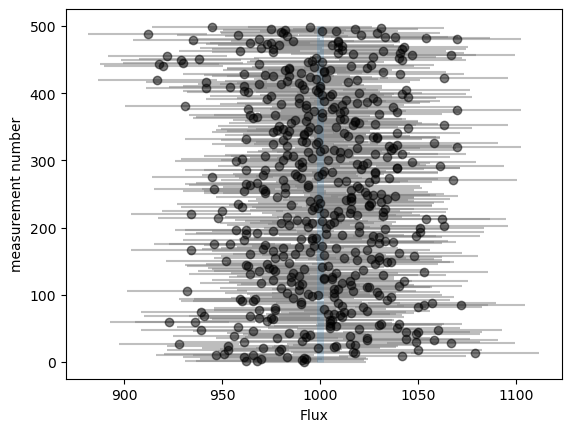

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.errorbar(F, np.arange(N), xerr=e, fmt='ok', ecolor='gray', alpha=0.5)
ax.vlines([F_true], 0, N, linewidth=5, alpha=0.2)
ax.set_xlabel("Flux");ax.set_ylabel("measurement number");

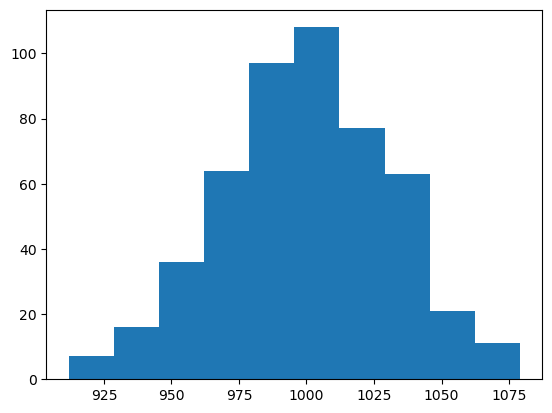

In [4]:
plt.figure()
plt.hist(F,bins=10)
plt.show()

# Difference between Frequentist and Bayesian Approach

## - Variation of data in terms of fixed model parameters. 

## - Variation of beliefs about the model parameters in terms of fixed observed data.

# Frequentist approach to Flux Measurement

Given a single observation, $D_i = (F_i, e_i)$, the probability distribution of the measurement given the true flux, $F$ given our assumption of Gaussian errors:

We construct the likelihood by computing the product of the probabilities for each data point:
# \begin{equation*}
{\cal{L}} = \prod_{i=1}^{N} P(D_i|F)
\end{equation*}

The negative of the log-likelihood is given as 
# \begin{equation*}
{\cal{L}} = -\frac{1}{2} \sum_{i=1}^{N} \{log(2 \pi e_i^2) + \frac{(F_i - F)^2}{e_i^2}\}
\end{equation*}

On maximising this likelihood which can be analytically solved in this simple case, we get

In [5]:
w = 1. / e ** 2
print("""
      F_true = {0}
      F_est  = {1:.0f} +/- {2:.0f} (based on {3} measurements)
      """.format(F_true, (w * F).sum() / w.sum(), w.sum() ** -0.5, N))


      F_true = 1000
      F_est  = 999 +/- 1 (based on 500 measurements)
      


# Bayesian Inference 

The fundamental result of interest is our knowledge of the parameters in question which is given by probability P(F|D). To compute this we apply the Bayes Theorem and get 

# \begin{equation*}
P(F|D) = \frac{P(D|F) P(F)}{P(D)}
\end{equation*}

What does each of the term means?

### - P(F|D): The posterior, which is the probability of the model parameters given the data.
### - P(D|F): The likelihood, which is proportional to the ${\cal{L}}(F|D )$ used in the frequentist approach.
### - P(F): The model prior, which encodes what we knew about the model before considering the data $D$.
### - P(D): The model evidence, also referred to as marginal likelihood, which in practice amounts to simply a normalization term.
This factor is the same for all possible hypotheses being considered, so this factor does not enter into determining the relative probabilities of different hypotheses.

If we set prior, $P(F) \propto 1$ i.e a flat prior or uniform prior or uninformative prior, we find 

# \begin{equation*}
P(F|D) \propto {\cal{L}}(F|D )
\end{equation*}

## That is, with a flat prior on $F$, the Bayesian posterior is maximized at precisely the same value as the frequentist result!


The prior allows inclusion of other information into the computation, which becomes very useful in cases where multiple measurement strategies are being combined to constrain a single model. The necessity to specify a prior, however, is one of the more controversial pieces of Bayesian analysis. A frequentist will point out that the prior is problematic when no true prior information is available. Though it might seem straightforward to use an uninformative prior like the flat prior mentioned above, there are some surprising subtleties involved. It turns out that in many situations, a truly uninformative prior cannot exist! Frequentists point out that the subjective choice of a prior which necessarily biases the result should have no place in scientific data analysis.
A Bayesian would counter that frequentism doesn’t solve this problem, but simply skirts the question. Frequentism can often be viewed as simply a special case of the Bayesian approach for some (implicit) choice of the prior: a Bayesian would say that it’s better to make this implicit choice explicit, even if the choice might include some subjectivity. Furthermore, as we will see below, the question frequentism answers is not always the question the researcher wants to ask.



In [6]:
def log_prior(theta):
    return 1  # flat prior

def log_likelihood(theta, F, e):
    return -0.5 * np.sum(np.log(2 * np.pi * e ** 2)
                         + (F - theta[0]) ** 2 / e ** 2)

def log_posterior(theta, F, e):
    return log_prior(theta) + log_likelihood(theta, F, e)

In [10]:
import numpy as np
ndim = 1  # number of parameters in the model
nwalkers = 50  # number of MCMC walkers
nburn = 200  # "burn-in" period to let chains stabilize i.e discard the first 200 steps of the total chain length. 
nsteps = 2000  # number of MCMC steps to take

# we'll start at random locations between 0 and 2000
starting_guesses = 2000 * np.random.rand(nwalkers, ndim)

import emcee
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=[F, e])
sampler.run_mcmc(starting_guesses, nsteps)

sample = sampler.chain  # shape = (nwalkers, nsteps, ndim)
sample = sampler.chain[:, nburn:, :].ravel()  # discard burn-in points

Text(0, 0.5, 'P(F)')

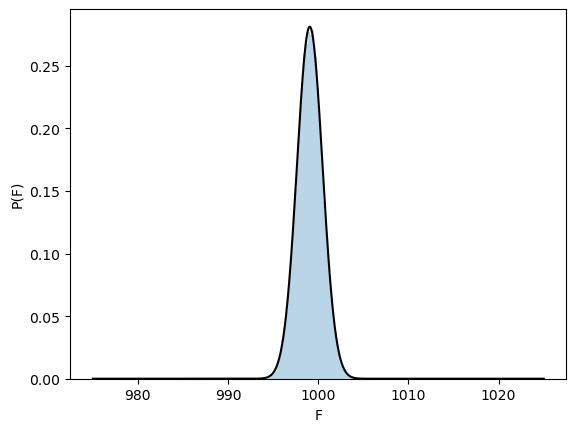

In [8]:
from scipy import stats
# plot a histogram of the sample
plt.hist(sample, bins=50, histtype="stepfilled", alpha=0.3, density=True)

# plot a best-fit Gaussian
F_fit = np.linspace(975, 1025,1000)
pdf = stats.norm(np.mean(sample), np.std(sample)).pdf(F_fit)

plt.plot(F_fit, pdf, '-k')
plt.xlabel("F"); plt.ylabel("P(F)")

In [9]:
print("""
      F_true = {0}
      F_est  = {1:.0f} +/- {2:.0f} (based on {3} measurements)
      """.format(F_true, np.mean(sample), np.std(sample), N))


      F_true = 1000
      F_est  = 999 +/- 1 (based on 500 measurements)
      


# Difference becomes apparent when in scenarios:

### - Handling nuisance parameters 
### - Interpretation of uncertainty 
### - Incorporation of prior information 
### - Comparison and evaluation of Models

# Nuisance parameters

### Nuisance parameters are those parameters that affect the final result, but are not otherwise of interest.

Example of a Billiard Game 

Consider a Billiard game is designed such that a ball is rolled on the board and if it falls on the prescribed side of Bob he gets a point and if it falls on the side of Alice, she gets a point. 
## The one who gets 6 points first wins the game. 

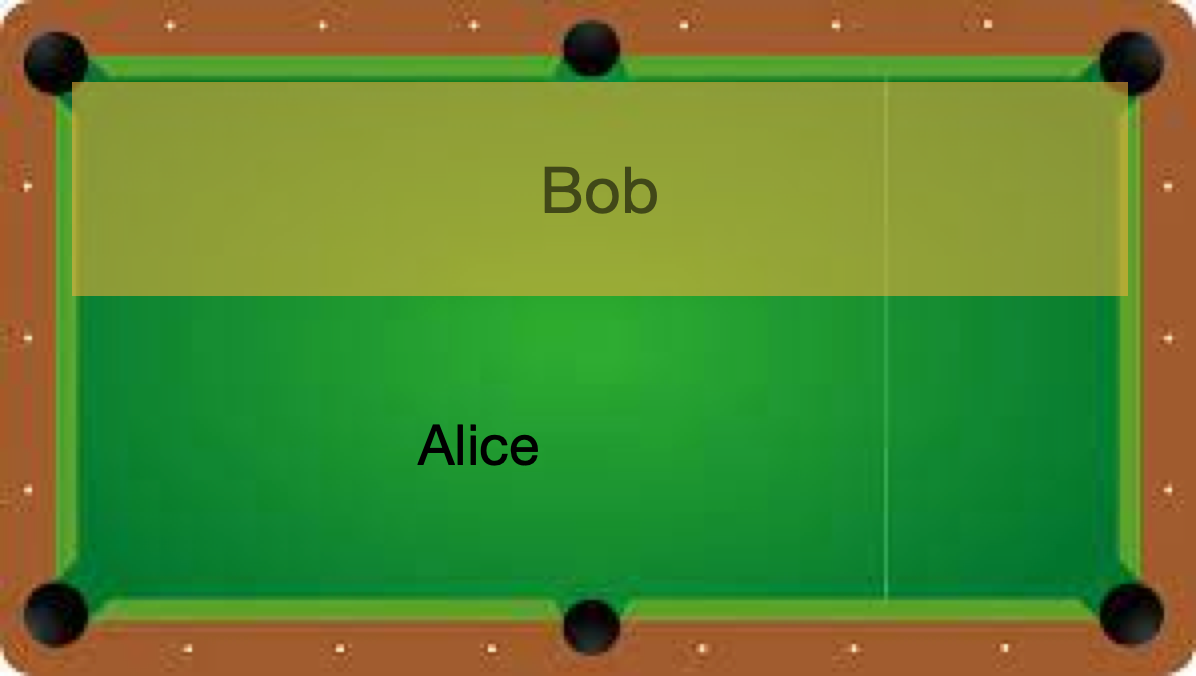

Now, consider the whole billiard table is black box for you. That is in other words, you do not know where the demarcation or the marker is size. What you just know is the results? 

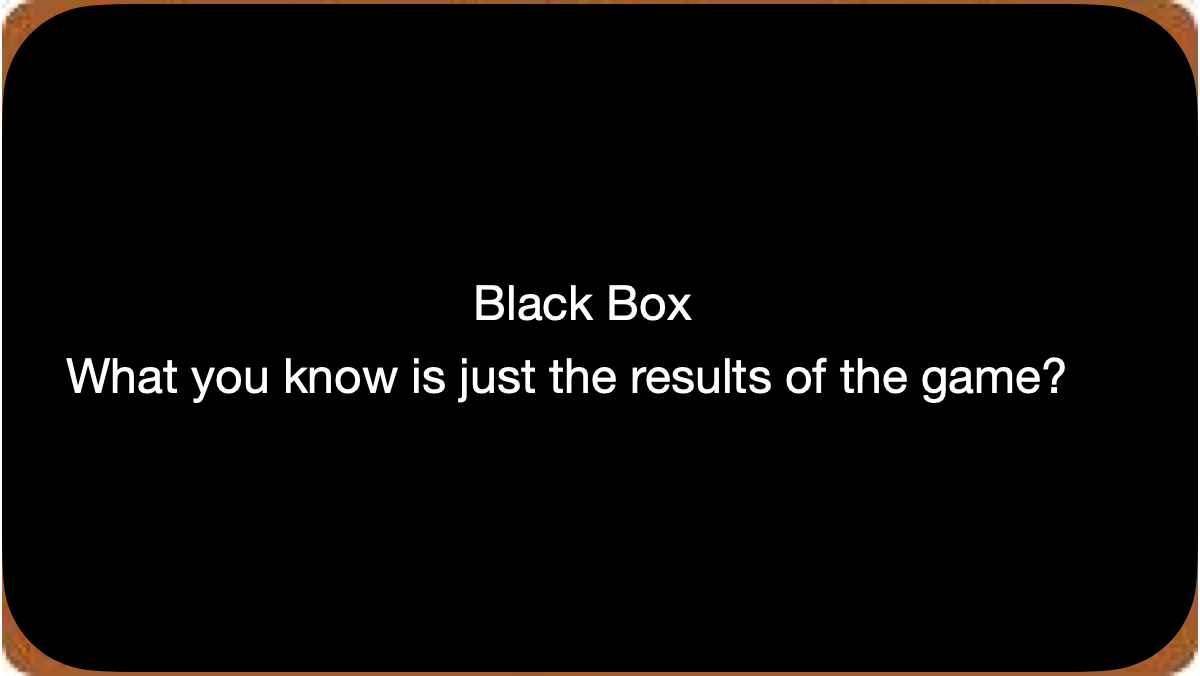

This is very similar to the scenario of what we do in science, right? You have some model (process) which gives rise to the some data. What you have is all the data and we need to figure out the model? 

But now let us ask the question, given a scenario, **Alice has got 5 points and Bob has got 3 points**, what are the odds that Bob will win? **In other words, what is the probability of Bob wins?**

### In this problem, the demarcation or the marker location decides who gets the point, and therefore the probability of its placement or location on the table, is the nuisance parameter. 

## In a Frequentist approach, 

the first thing would be determine the location of this demarcation. 

Given the above observation, **we can quantify this marker placement as a probability p that any given roll lands in Alice’s favor**. In other words, p is defined as the probability that a ball lands on Alice’s side during the current game. 

Now the frequentist approach would be such that given a demarcation that favors Alice, the maximum likelihood estimate of p is 
### p = 5/8  

To answer the question what are the odds Bob wins this game is that in the next consecutive three turns he has to gain point to win, which means 

# \begin{equation*}
P(Bwins) = (1- p)^3
\end{equation*}

### which is nearly $5.3\%$.


## In Bayesian Approach

A Bayesian approach to this problem involves marginalizing (i.e. integrating) over the unknown p so that, assuming the prior is accurate. 

Here we want to estimate P(Bwins|Data), where data is (nA,nB) = (5,3). In words, the probability that Bob wins given the observation that Alice currently has five points to Bob’s three. 

This is marginal probability of P(Bwins|D) for irrespective of what p is ?


# \begin{equation*}
P(Bwins|D) =  \int_{-\infty}^{+\infty} P(Bwins,p|D) dp
\end{equation*}

### Given the observed data $D$, what is the probability distribution over: the event that Bob wins, and the value of the demarcation p?”

# \begin{equation*}
P(Bwins|D) =  \int_{-\infty}^{+\infty} P(Bwins|p,D) P(p|D) dp
\end{equation*}

### Probability that Bob wins given $p$ and data, times the posterior of $p$ given data.


Now applying the Bayes theorem on the P(p|D), we get 

# \begin{equation*}
P(Bwins|D) =  \frac{\int P(Bwins|p,D) P(D|p) P(p)} {P(D)} dp
\end{equation*}

which is 

# \begin{equation*}
P(Bwins|D) =  \frac{\int P(Bwins|p,D) P(D|p) P(p) dp} {\int P(D|p) P(p) dp}
\end{equation*}


Each term on right side 

- P(Bwins|p,D): This the probability that relates to what is the probability Bob wins given a demarcation p and the data, which is equivalent to what is obtained in the frequentist approach and is equal to $(1-p)^3$

- P(D|p): Given a probability p, what is the likelihood of exactly 5 positive outcomes out of eight trials? The answer comes from the Binomial distribution: $P(D|p) \propto p^5(1− p)^3$

- P(p): this is our prior on the probability p. By the problem definition, we can assume that p is evenly drawn between 0 and 1. That is, $P(p) \propto 1$ for 0 ≤ p ≤1.


Putting this all together in the above equation, we get
## P(Bwins|D) = $9.1\%$



Who is correct?

For a simple problem like this, we can answer this question empirically by simulating a large number of games and count the fraction of suitable games which Bob goes on to win. The result of such a simulation confirms the Bayesian result: $9.2\%$ against Bob winning.

Is frequentism wrong? Not necessarily: in this case, the incorrect result is more a matter of the approach being “naïve” than it being “frequentist”. The approach above does not consider how p may vary. This may be included by employing special frequentist approaches.

Bayes allows the nuisance parameter to vary through marginalisation. 

Bayesianism provides a more natural framework for handling nuisance parameters: by simple algebraic manipulation of a few well- known axioms of probability interpreted in a Bayesian sense, we straightforwardly arrive at the correct answer without need for other special statistical expertise.

# Confidence Interval Versus Credible region

## Frequentist:
### Confidence interval: If an experiment is repeated N number of times, 95% of the computed confidence intervals will contain the true value of $\theta$.

In this approach the true value is fixed and the confidence interval can vary as you vary the number of your experiments. 

For example, you generate N random samples from the same target population and with the same sample size would yield N Confidence intervals that contain the true estimate in a distribution corresponding to a chosen confidence level. 


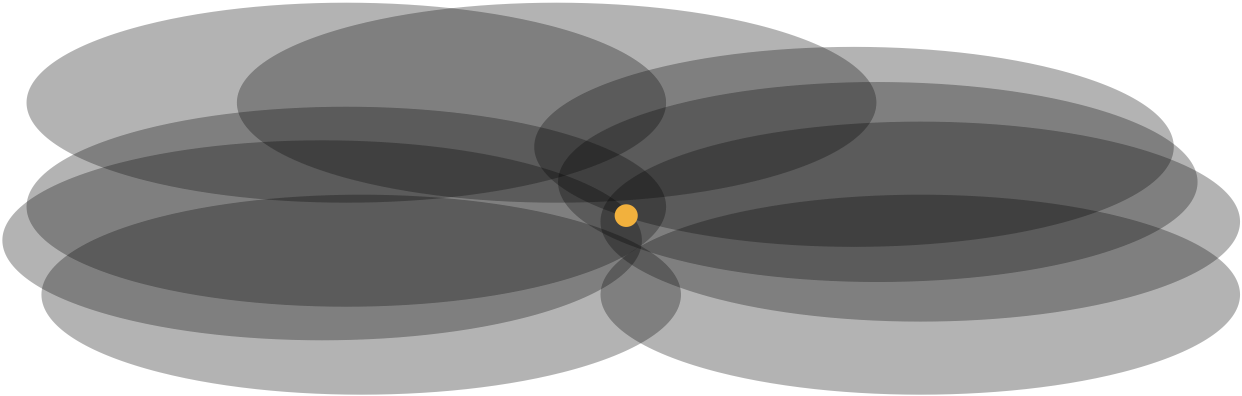

## This is a probabilistic statement about the recipe for generating confidence interval given a fixed model parameter. 

**Key Clarifications**

- A single confidence interval either does or does not contain the true value. The 95% refers to the long-run frequency of correct intervals.
- The true parameter is fixed, but the confidence intervals vary with different samples.
- Confidence intervals depend on sample variability—larger samples lead to narrower intervals.

**Example**

Imagine measuring the average height of students in a school. If we take 100 random samples and compute $95\%$ confidence intervals each time, about $95$ of them will include the true average height, while $\sim5$ will not.


## It is INCORRECT to say => “There is a 95% probability that the true value lies in this interval”

## Bayesian:
### Credible region: Given our observed data, there is a 95% probability that the given value will lie within the credible region. 

In this approach, the credible region is fixed, and the value of $\theta$ can vary. Credible region is that interval on the posterior probability distribution within which an unobserved parameter value falls with a particular probability.

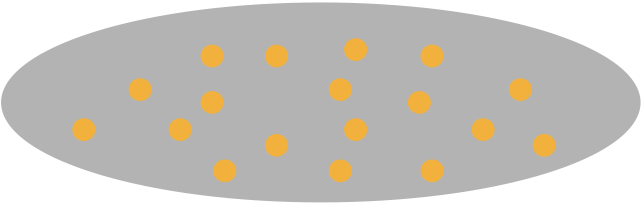

## This is a probabilistic statement about the model parameters given a fixed credible region

### Now, the problem in a frequentist approach is 

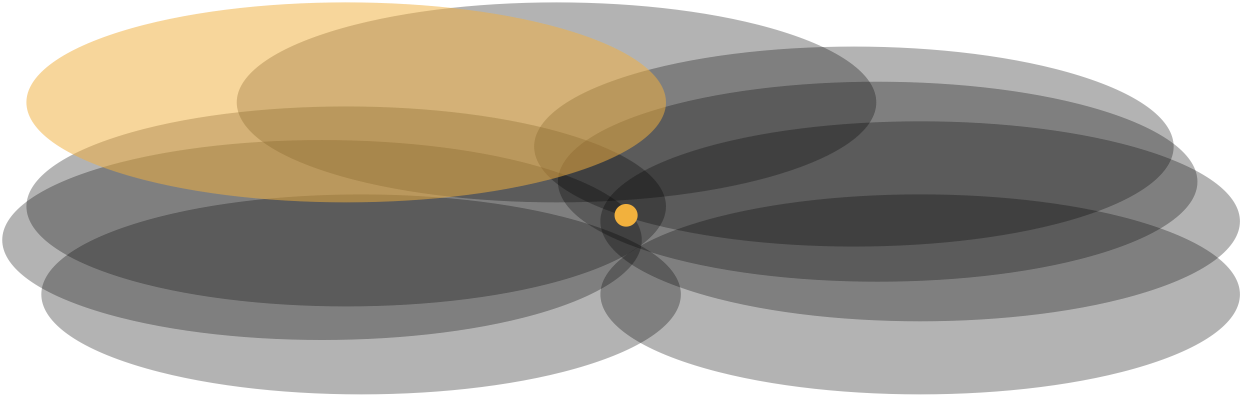

In practice, it is quite complicated to have several random samples drawn from the same population so we take a single sample of the population of interest and calculate the confidence interval for that sample. Let us say it is the one shown in yellow above. Now, this CI does not contain my true value. 


A confidence interval is “correct” only in the sense that, over many repeated experiments, the method used to construct it will contain the true value a certain fraction of the time.

## Remember:
## In general, a frequentist 95% confidence interval is not 95% likely to contain the true value! 

# Hypothesis Testing and Bayes Factor 

**The Bayes factor is the ratio of two marginal likelihoods; that is, the likelihoods of two statistical models integrated over the prior probabilities of their parameters.** 

Given a model selection problem in which one wishes to choose between two models on the basis of observed data $D$, the plausibility of the two different models $M1$ and $M2$, parametrised by model parameter vectors $\theta _{1}$  and $\theta _{2}$, is assessed by the Bayes factor $K$ given by

## \begin{equation*}
K = \frac{P(D|M1)}{P(D|M2)} =\frac{\frac{P(M1|D) P(D)}{P(M1)}}{\frac{P(M2|D) P(D)}{P(M2)}} = \frac{P(M1|D) P(M2)}{P(M2|D) P(M1)}
\end{equation*}

**If prior probabilities for the two models are the same, then the Bayes factor is equal to the ratio of the posterior probabilities of M1 and M2.** 

If instead of the Bayes factor integral, the likelihood corresponding to the maximum likelihood estimate of the parameter for each statistical model is used, then the test becomes a classical likelihood-ratio test. Unlike a likelihood-ratio test, this Bayesian model comparison does not depend on any single set of parameters, as it integrates over all parameters in each model 

## Problem

A simple three-parameter linear model which fits a straight-line to data with unknown errors. 
The parameters will be the the y-intercept, $\alpha$, the slope $\beta$, and the (unknown) normal scatter $\sigma$ about the line.

# $ y = \alpha + \beta x + \sigma$

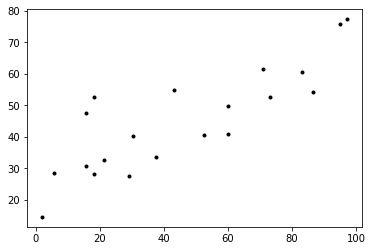

In [63]:
import numpy as np
np.random.seed(42) # for repeatability 
alpha_true = 25
beta_true = 0.5
theta_true = (alpha_true, beta_true)
sigma_true = 10
xdata = 100 * np.random.random(20)
ydata = theta_true[0] + theta_true[1] * xdata 
ydata = np.random.normal(ydata, sigma_true) # add error

plt.figure()
plt.plot(xdata,ydata,'k.')
plt.show()

### Frequentist Approach Solution

In [57]:
import statsmodels.api as sm   # version 0.5 
X = sm.add_constant(xdata)
print(X)
result = sm.OLS(ydata, X).fit()   #Ordinary Least Squares fitting
sigma_hat = result.params
Sigma = result.cov_params() 
print(result.summary2())
print(sigma_hat)
print(Sigma) 

[[ 1.         37.45401188]
 [ 1.         95.07143064]
 [ 1.         73.19939418]
 [ 1.         59.86584842]
 [ 1.         15.60186404]
 [ 1.         15.59945203]
 [ 1.          5.80836122]
 [ 1.         86.61761458]
 [ 1.         60.11150117]
 [ 1.         70.80725778]
 [ 1.          2.05844943]
 [ 1.         96.99098522]
 [ 1.         83.24426408]
 [ 1.         21.23391107]
 [ 1.         18.18249672]
 [ 1.         18.34045099]
 [ 1.         30.4242243 ]
 [ 1.         52.47564316]
 [ 1.         43.19450186]
 [ 1.         29.12291402]]
                 Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.683   
Dependent Variable: y                AIC:                147.7737
Date:               2022-10-19 23:04 BIC:                149.7651
No. Observations:   20               Log-Likelihood:     -71.887 
Df Model:           1                F-statistic:        41.97   
Df Residuals:       18               Prob (F-statistic): 4.30e-06
R-squared:    

### Bayesian Approach Solution
### Using emcee

In [41]:
import emcee # version 2.0 def log_prior(theta):

def log_prior(theta):
    alpha, beta, sigma = theta 
    if sigma < 0:
        return -np.inf # log(0) 
    else:
        return (-1.5 * np.log(1 + beta**2) - np.log(sigma))

def log_like(theta, x, y):
    alpha, beta, sigma = theta
    y_model = alpha + beta * x
    return -0.5 * np.sum(np.log(2*np.pi*sigma**2) +(y-y_model)**2 / sigma**2) 

def log_posterior(theta, x, y):
    return log_prior(theta) + log_like(theta,x,y)


In [59]:
ndim = 3 # number of parameters in the model 
nwalkers = 50 # number of MCMC walkers
nburn = 1000 # "burn-in" to stabilize chains 
nsteps = 2000 # number of MCMC steps to take 
starting_guesses = np.random.rand(nwalkers, ndim)    

In [60]:
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior,args=[xdata,ydata]) 
sampler.run_mcmc(starting_guesses, nsteps)

State([[24.02165963  0.47774304  9.13964243]
 [27.49240282  0.47821702  8.81571151]
 [19.32535028  0.60993609 16.69550876]
 [20.72080982  0.56104811  9.60741137]
 [25.63180122  0.43733126  9.74383316]
 [17.98701919  0.59638209  9.86149077]
 [27.24853771  0.42982093  9.647305  ]
 [24.05667823  0.41358593  8.51141618]
 [25.93226138  0.40109552  7.26445511]
 [25.67805857  0.43161063  8.44133908]
 [26.47520581  0.42167015  8.57307778]
 [29.0316853   0.35751649 11.27393025]
 [25.30197028  0.4369036   8.12117654]
 [28.51793193  0.48073677  9.60097498]
 [22.37867031  0.47416028  8.38800319]
 [33.31000657  0.275437   11.89209933]
 [24.49245725  0.42729717  7.60789177]
 [25.94776517  0.43720557  8.98308864]
 [23.37778931  0.57044163 14.87589568]
 [27.02517986  0.39083964  8.69428692]
 [28.17694711  0.39257822 10.16686761]
 [26.29720694  0.43138582  8.02180568]
 [25.73392695  0.46801904  9.97348053]
 [27.98520502  0.45186775  8.32169978]
 [25.67476149  0.40539854  7.08446692]
 [22.61432164  0.45

In [61]:
# chain is of shape (nwalkers, nsteps, ndim): 
# discard burn-in points and reshape:
trace = sampler.chain[:, nburn:, :]
print(trace)
trace = trace.reshape(-1, ndim).T

[[[24.20713002  0.44383439  9.4042763 ]
  [24.20713002  0.44383439  9.4042763 ]
  [24.73762147  0.44710401  9.46828551]
  ...
  [23.64326503  0.51525561  7.82097931]
  [24.02165963  0.47774304  9.13964243]
  [24.02165963  0.47774304  9.13964243]]

 [[27.10529448  0.40856958  9.46826675]
  [27.01913959  0.4111922   9.40721312]
  [27.21651359  0.40932952  9.59743796]
  ...
  [27.49356252  0.47829358  8.81721956]
  [27.49240282  0.47821702  8.81571151]
  [27.49240282  0.47821702  8.81571151]]

 [[31.97703813  0.26439415  9.38523481]
  [31.97703813  0.26439415  9.38523481]
  [30.98799365  0.28531041  9.78519945]
  ...
  [19.32535028  0.60993609 16.69550876]
  [19.32535028  0.60993609 16.69550876]
  [19.32535028  0.60993609 16.69550876]]

 ...

 [[20.30766767  0.47132455  8.13424241]
  [21.00968387  0.45543134  8.48636833]
  [19.41062523  0.47170391  8.46234568]
  ...
  [27.00936961  0.41697865 11.39615642]
  [28.18259234  0.41265234 11.65385304]
  [28.125405    0.41424482 11.55237836]]

 [

In [62]:
print(trace)

[[24.20713002 24.20713002 24.73762147 ... 29.25117449 29.25117449
  27.90048978]
 [ 0.44383439  0.44383439  0.44710401 ...  0.41666322  0.41666322
   0.42773434]
 [ 9.4042763   9.4042763   9.46828551 ...  8.66955826  8.66955826
   8.9958821 ]]


50000 50000


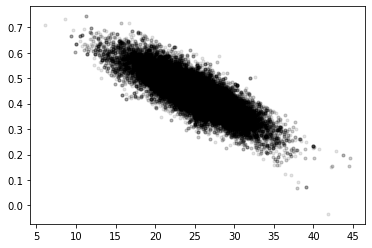

In [46]:
print(len(trace[0]),len(trace[1]))
import matplotlib.pyplot as plt
plt.figure()
plt.plot(trace[0],trace[1],'k.',alpha=0.1)
plt.show()

(3, 50000)


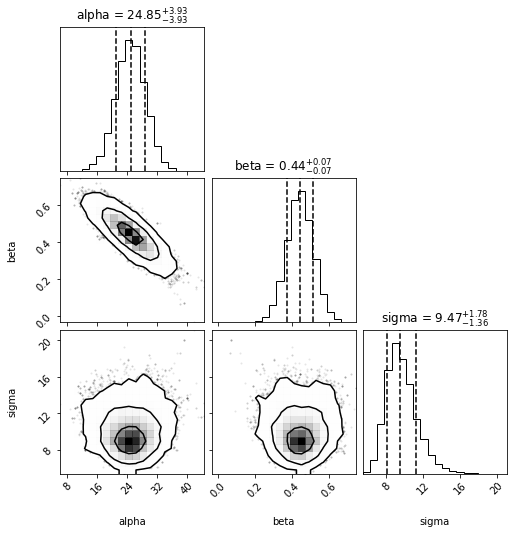

In [64]:
#How to make corner plot ?
# https://corner.readthedocs.io/en/latest/pages/quickstart/
# For understanding how to define the confidence level of contours, refer https://corner.readthedocs.io/en/latest/pages/sigmas/

print(trace.shape)
import corner

fig = corner.corner(
   trace.T, labels=['alpha','beta','sigma'],quantiles=[0.16, 0.5, 0.84],show_titles=True,levels=((1 - np.exp(-(1)**2 /2)), (1 - np.exp(-(2)**2 /2)), (1 - np.exp(-(3)**2 /2))))



The corner plot shows all the one and two dimensional projections of the posterior probability distributions of your parameters. This is useful because it quickly demonstrates all of the covariances between parameters.

Other MCMC python packages:
- The PyMC package [Patil2010] is an MCMC implementation written in Python and Fortran. It makes use of the classic Metropolis-Hastings MCMC sampler.

- PyStan is the official Python interface to Stan, a probabilistic programming language implemented in C++ and making use of a Hamiltonian MCMC using a No U-Turn Sampler. 